# 02 - Leakage-Safe Splits

Builds the train / validation / test partitions for both datasets and **proves** they
are leakage-free with executable audits. This notebook is the methodological core of
the revision; everything downstream inherits its guarantees.

## What counts as leakage here

| Leak | Where it comes from | Control |
|---|---|---|
| **Sample-level** | 75% window overlap (Tomasov) | guard bands: reject any window whose raw samples are also read by another split |
| **Recording-level** | many windows carved from one continuous recording | split on whole groups (Cao: session, Tomasov: contiguous recording segment) |
| **Resampling-level** | SMOTE fitted before splitting | resamplers live inside an `imblearn` Pipeline (notebook 06) |
| **Selection-level** | feature selection fitted on all data | selectors fitted on training folds only (notebook 05) |
| **Scaling-level** | scaler fitted on train+test | `StandardScaler` inside the same Pipeline |

The first two are handled here. The audits at the end of each section **raise** if any
guarantee is violated, so a broken split cannot silently propagate.

In [1]:
import sys
from pathlib import Path
EXPERIMENT_DIR = Path(r"/mnt/b6bdcd1c-136a-435b-aeed-0e1b31c32749/Paper_Reeyan/Experiment")
if str(EXPERIMENT_DIR) not in sys.path:
    sys.path.insert(0, str(EXPERIMENT_DIR))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dasfe import config as C, splits as S

sns.set_theme(style="whitegrid", context="notebook")
rng = np.random.default_rng(C.SEED)

cao = pd.read_parquet(C.results_dir("cao", "00_inventory") / "manifest.parquet")
tom = pd.read_parquet(C.results_dir("tomasov", "00_inventory") / "manifest.parquet")
print(f"cao     {len(cao):,} records")
print(f"tomasov {len(tom):,} windows")

cao     15,419 records
tomasov 439,754 windows


## 1. Cao - session-grouped split

The split group is the recording session (`date|operator|class|session`). Whole
sessions go to one split, so no two samples carved from the same continuous recording
can straddle the boundary.

`StratifiedGroupKFold` with 10 folds is merged 8/1/1, keeping class proportions as
close as the group structure permits.

In [2]:
cao = cao[cao.n_bytes > 0].reset_index(drop=True)   # drop the corrupt zero-byte record
cao["split"] = S.grouped_three_way_split(cao, group_key="session_id", seed=C.SEED)

report_cao = S.split_report(cao, "session_id")
display(report_cao)

print("\nsplit proportions:")
print((cao.split.value_counts(normalize=True).round(4) * 100).to_string())

,test,train,val,test_groups,train_groups,val_groups
label,,,,,,
background,227,2311,407,4,50,9
dig,370,1931,211,10,59,6
knock,622,1802,106,12,43,5
shake,134,2533,61,3,58,2
walk,232,1844,374,4,46,8
water,218,1734,301,11,95,16
TOTAL,1803,12155,1460,44,351,46



split proportions:
split
train    78.84
test     11.69
val       9.47


In [3]:
print("=== Cao leakage scorecard ===")
card_cao = S.leakage_scorecard(cao, group_key="session_id")
display(card_cao)

# Hard assertions - these raise on failure.
S.assert_group_disjoint(cao, "session_id")
S.assert_no_duplicate_ids(cao)
print("\nPASS: no recording session appears in more than one split.")

overlap = (cao.groupby("session_id").split.nunique() > 1).sum()
print(f"sessions spanning >1 split: {overlap}   (published split: 423)")

=== Cao leakage scorecard ===


,check,status,detail
0,groups of 'session_id' disjoint across splits,PASS,
1,no duplicate sample_id,PASS,
2,all classes present in all splits,PASS,



PASS: no recording session appears in more than one split.
sessions spanning >1 split: 0   (published split: 423)


### 1.1 Operator and date overlap

Session-grouping does *not* prevent the same operator or the same day appearing in two
splits, and that is intentional: forbidding it would leave several classes without
training data. The stricter leave-one-date-out protocol in notebook 08 answers the
harder cross-campaign question separately.

operator : 13/16 values appear in more than one split
date     : 19/21 values appear in more than one split


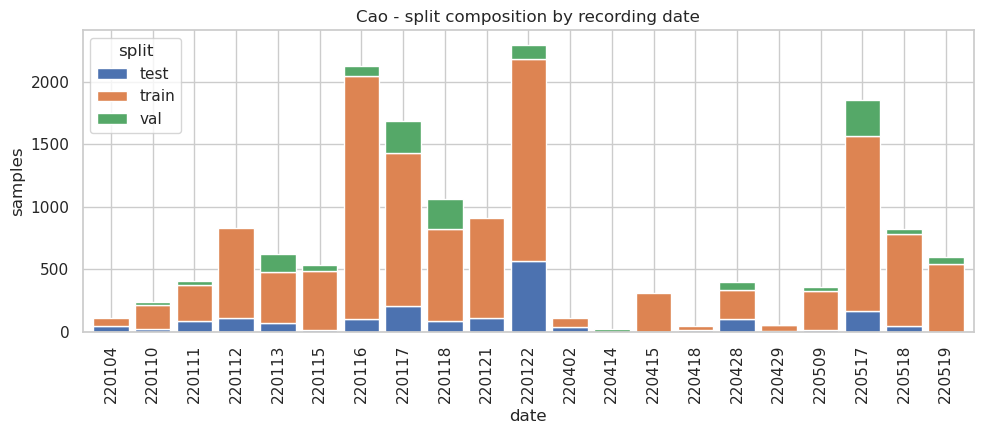

In [4]:
for key in ("operator", "date"):
    n_multi = int((cao.groupby(key).split.nunique() > 1).sum())
    print(f"{key:9s}: {n_multi}/{cao[key].nunique()} values appear in more than one split")

pivot = pd.crosstab(cao.date, cao.split)
fig, ax = plt.subplots(figsize=(10, 4.5))
pivot.plot(kind="bar", stacked=True, ax=ax, width=0.85)
ax.set_title("Cao - split composition by recording date")
ax.set_xlabel("date"); ax.set_ylabel("samples")
plt.tight_layout()
plt.savefig(C.results_dir("cao", "01_splits") / "split_by_date.png", dpi=200)
plt.show()

## 2. Tomasov - blocked split with guard bands

Five of the nine classes come from a single recording, so a leave-one-recording-out
split is impossible. The split therefore happens *inside* each recording:

1. Cut each recording's timeline into `N_SEGMENTS` **contiguous equal-mass** segments -
   each segment holds ~1/N of that recording's annotated windows.
2. Assign whole segments to train / val / test, rotating which segments are held out so
   the test data is not always the tail of the timeline.
3. Drop every window whose raw-sample span touches, or comes within `GUARD_BLOCKS` of, a
   block read by a different split.

### Why equal *mass* and not equal duration

A first attempt used `StratifiedGroupKFold` over fixed-duration zones. It balances the
*number of groups* per fold, but a Tomasov zone holds anywhere from ~30 to ~8,000
windows depending on how many loci the event touches. The result was a 92/5/2 split with
`openclose` receiving **no test samples at all**. Cutting by window mass instead fixes
both: proportions hold per class, and every recording - hence every class - contributes
to all three splits.

In [5]:
assigned = S.blocked_split_by_recording(
    tom, recording_col="recording_id", block_col="block",
    n_segments=C.N_SEGMENTS, fractions=C.SPLIT_FRACTIONS, seed=C.SEED,
)
tom = tom.join(assigned)
before = len(tom)

print(f"{C.N_SEGMENTS} contiguous segments per recording -> "
      f"{tom.group_id.nunique()} split groups")
print("\nbefore guard band:")
display(S.split_report(tom, "group_id"))
print("\nsplit proportions:")
print((tom.split.value_counts(normalize=True).round(4) * 100).to_string())

10 contiguous segments per recording -> 160 split groups

before guard band:


,test,train,val,test_groups,train_groups,val_groups
label,,,,,,
car,5767,46441,5809,4,32,4
construction,5551,43895,5386,1,8,1
fence,4475,35089,4417,3,24,3
longboard,1525,12279,1563,2,16,2
manipulation,1774,14176,1760,1,8,1
openclose,681,5476,635,1,8,1
regular,21153,167924,20946,1,8,1
running,1386,11112,1379,1,8,1
walk,1917,15329,1909,2,16,2



split proportions:
split
train    79.98
test     10.06
val       9.96


In [6]:
keep = S.apply_temporal_guard(tom, split_col="split",
                              recording_col="recording_id", block_col="block")
tom_guarded = tom[keep].reset_index(drop=True)
dropped = before - len(tom_guarded)

print(f"guard band = {C.GUARD_BLOCKS} blocks "
      f"({C.GUARD_BLOCKS*C.WIN_HOP:,} raw samples = one full window)")
print(f"dropped {dropped:,} boundary windows ({100*dropped/before:.2f}% of the annotated set)")
print(f"remaining: {len(tom_guarded):,}\n")

report_tom = S.split_report(tom_guarded, "group_id")
display(report_tom)
print("\nsplit proportions after guard:")
print((tom_guarded.split.value_counts(normalize=True).round(4) * 100).to_string())

guard band = 4 blocks (8,192 raw samples = one full window)
dropped 39,560 boundary windows (9.00% of the annotated set)
remaining: 400,194



,test,train,val,test_groups,train_groups,val_groups
label,,,,,,
car,3046,43485,3324,2,31,3
construction,4102,42341,3946,1,8,1
fence,1983,33432,2700,3,24,2
longboard,581,11671,1052,1,16,2
manipulation,867,13519,1163,1,8,1
openclose,198,5280,336,1,8,1
regular,17661,163253,15356,1,8,1
running,929,10811,1057,1,8,1
walk,1661,14900,1540,2,16,2



split proportions after guard:
split
train    84.63
test      7.75
val       7.61


In [7]:
print("=== Tomasov leakage scorecard ===")
card_tom = S.leakage_scorecard(tom_guarded, group_key="group_id")
display(card_tom)

# The decisive audit: reconstruct which raw sample blocks each split reads and
# verify the sets are pairwise disjoint inside every recording.
S.assert_group_disjoint(tom_guarded, "group_id")
S.assert_no_duplicate_ids(tom_guarded)
S.assert_no_sample_overlap(tom_guarded)
assert card_tom.status.eq("PASS").all(), "a leakage check failed - do not proceed"
print("\nPASS: no raw interrogator sample is read by windows in two different splits,")
print("      and every class is represented in every split.")

=== Tomasov leakage scorecard ===


,check,status,detail
0,groups of 'group_id' disjoint across splits,PASS,
1,no duplicate sample_id,PASS,
2,no raw-sample overlap between splits,PASS,
3,all classes present in all splits,PASS,



PASS: no raw interrogator sample is read by windows in two different splits,
      and every class is represented in every split.


### 2.1 Counter-example: what the original random split does

The same audit applied to a random stratified split - the protocol used in the
submitted version - shows how much of the test set is contaminated.

In [8]:
from sklearn.model_selection import train_test_split

idx = np.arange(len(tom))
tr, rest = train_test_split(idx, train_size=0.8, stratify=tom.label, random_state=C.SEED)
va, te = train_test_split(rest, train_size=0.5, stratify=tom.label.iloc[rest], random_state=C.SEED)
naive = tom.copy()
naive["split"] = "train"
naive.loc[naive.index[va], "split"] = "val"
naive.loc[naive.index[te], "split"] = "test"

print("random stratified 80/10/10 (original protocol):")
display(S.leakage_scorecard(naive, group_key="group_id"))

random stratified 80/10/10 (original protocol):


,check,status,detail
0,groups of 'group_id' disjoint across splits,FAIL,160 group(s) of 'group_id' appear in more than...
1,no duplicate sample_id,PASS,
2,no raw-sample overlap between splits,FAIL,raw-sample overlap between splits in 48 record...
3,all classes present in all splits,PASS,


In [9]:
# Quantify it: how many test windows share raw samples with a training window?
bpw = C.WIN_LEN // C.WIN_HOP
contaminated = 0
for rec, sub in naive.groupby("recording_id"):
    n_blocks = int(sub.block.max()) + bpw + 1
    train_cov = np.zeros(n_blocks, dtype=bool)
    b_tr = sub.loc[sub.split == "train", "block"].to_numpy()
    for off in range(bpw):
        train_cov[b_tr + off] = True
    b_te = sub.loc[sub.split == "test", "block"].to_numpy()
    hit = np.zeros(b_te.size, dtype=bool)
    for off in range(bpw):
        hit |= train_cov[b_te + off]
    contaminated += int(hit.sum())

n_test = int((naive.split == "test").sum())
print(f"random split : {contaminated:,} / {n_test:,} test windows "
      f"({100*contaminated/n_test:.1f}%) share raw samples with a training window")

# And the same measurement on the revised split.
contaminated2 = 0
for rec, sub in tom_guarded.groupby("recording_id"):
    n_blocks = int(sub.block.max()) + bpw + 1
    train_cov = np.zeros(n_blocks, dtype=bool)
    b_tr = sub.loc[sub.split == "train", "block"].to_numpy()
    for off in range(bpw):
        train_cov[b_tr + off] = True
    b_te = sub.loc[sub.split == "test", "block"].to_numpy()
    if b_te.size == 0:
        continue
    hit = np.zeros(b_te.size, dtype=bool)
    for off in range(bpw):
        hit |= train_cov[b_te + off]
    contaminated2 += int(hit.sum())

n_test2 = int((tom_guarded.split == "test").sum())
print(f"revised split: {contaminated2:,} / {n_test2:,} test windows "
      f"({100*contaminated2/max(n_test2,1):.1f}%)")

leak_table = pd.DataFrame([
    {"protocol": "random stratified 80/10/10 (submitted)",
     "test windows": n_test, "contaminated": contaminated,
     "contaminated %": round(100*contaminated/n_test, 2)},
    {"protocol": "blocked segment + guard band (revised)",
     "test windows": n_test2, "contaminated": contaminated2,
     "contaminated %": round(100*contaminated2/max(n_test2,1), 2)},
])
display(leak_table)
leak_table.to_csv(C.results_dir("shared", "tables") / "leakage_comparison_tomasov.csv", index=False)

random split : 43,976 / 43,976 test windows (100.0%) share raw samples with a training window
revised split: 0 / 31,028 test windows (0.0%)


,protocol,test windows,contaminated,contaminated %
0,random stratified 80/10/10 (submitted),43976,43976,100.0
1,blocked segment + guard band (revised),31028,0,0.0


### 2.2 Visualising the split along the timeline

Each recording's 21-second timeline, coloured by split. The white slivers are the
guard bands - windows deleted so that no raw sample is shared.

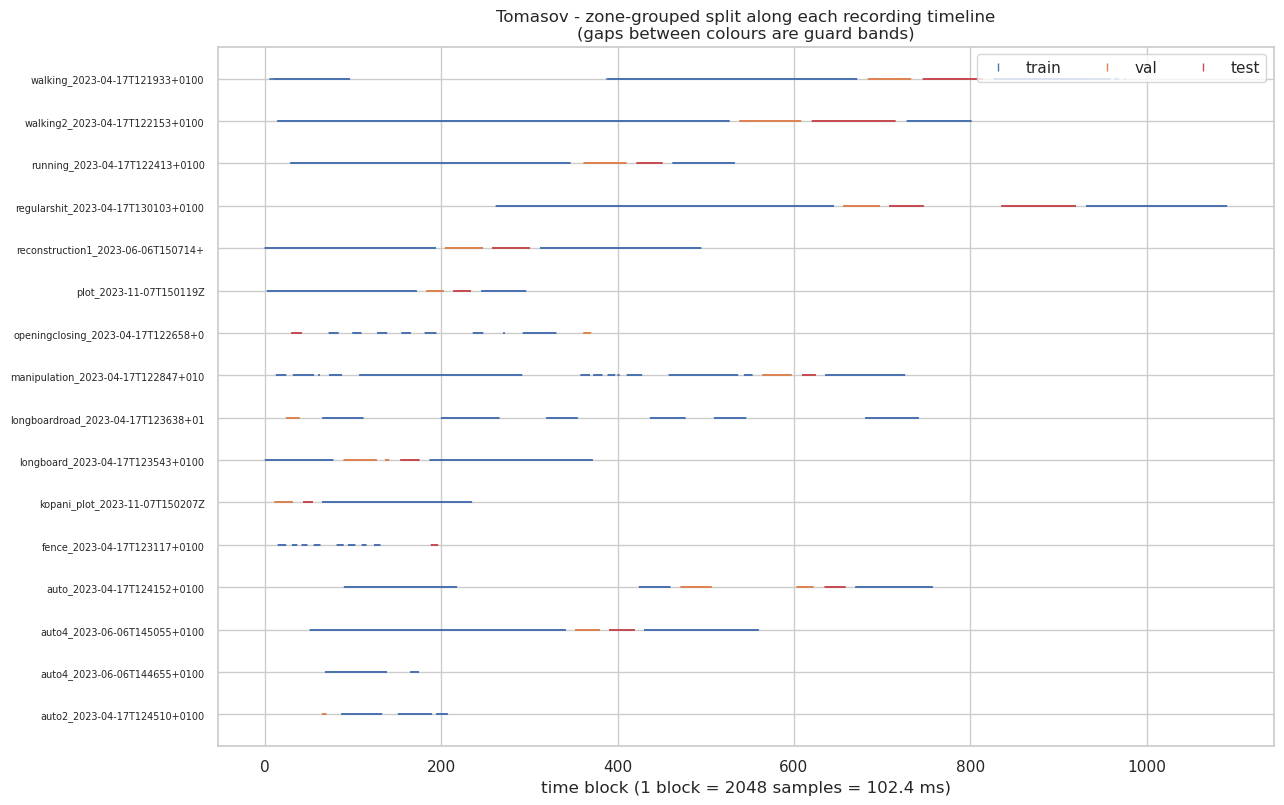

In [10]:
colors = {"train": "#4C72B0", "val": "#DD8452", "test": "#C44E52"}
recs = sorted(tom_guarded.recording_id.unique())

fig, ax = plt.subplots(figsize=(13, 0.42 * len(recs) + 1.5))
for i, rec in enumerate(recs):
    sub = tom_guarded[tom_guarded.recording_id == rec]
    for split, s2 in sub.groupby("split"):
        ax.scatter(s2.block, np.full(len(s2), i), s=2,
                   c=colors[split], marker="|", alpha=0.6)
ax.set_yticks(range(len(recs)))
ax.set_yticklabels([f"{r[:34]}" for r in recs], fontsize=7)
ax.set_xlabel("time block (1 block = 2048 samples = 102.4 ms)")
ax.set_title("Tomasov - zone-grouped split along each recording timeline\n"
             "(gaps between colours are guard bands)")
handles = [plt.Line2D([], [], color=c, marker="|", ls="", label=k) for k, c in colors.items()]
ax.legend(handles=handles, loc="upper right", ncol=3)
plt.tight_layout()
plt.savefig(C.results_dir("tomasov", "01_splits") / "split_timeline.png", dpi=200)
plt.show()

## 3. Class-balance decimation (applied *after* splitting)

The submitted version decimated the three largest classes (`car`, `construction`,
`regular`) before splitting. Decimating after splitting is equivalent in effect and
strictly safer, because the split geometry cannot be influenced by which samples
survive.

Set `DECIMATE = False` to keep the full imbalance and rely on the balancing
strategies alone.

In [11]:
DECIMATE = True
CAPS = {"regular": 12350, "car": 29010, "construction": 27420}   # the paper's targets

def decimate(df, caps, seed=C.SEED):
    """Cap over-represented classes, sampling proportionally within each split."""
    parts = []
    for (label, split), sub in df.groupby(["label", "split"], sort=False):
        cap = caps.get(label)
        if cap is None:
            parts.append(sub); continue
        frac = cap / (df.label == label).sum()
        n = max(1, int(round(frac * len(sub))))
        parts.append(sub.sample(n=min(n, len(sub)), random_state=seed))
    return pd.concat(parts).sort_index()

if DECIMATE:
    tom_final = decimate(tom_guarded, CAPS)
    print(f"{len(tom_guarded):,} -> {len(tom_final):,} windows after decimation")
else:
    tom_final = tom_guarded

display(pd.crosstab(tom_final.label, tom_final.split, margins=True))

# Decimation must not have broken the guarantees.
S.assert_group_disjoint(tom_final, "group_id")
S.assert_no_sample_overlap(tom_final)
print("\nPASS: guarantees survive decimation.")

400,194 -> 172,458 windows after decimation


split,test,train,val,All
label,,,,
car,1772,25303,1934,29009
construction,2232,23041,2147,27420
fence,1983,33432,2700,38115
longboard,581,11671,1052,13304
manipulation,867,13519,1163,15549
openclose,198,5280,336,5814
regular,1111,10272,966,12349
running,929,10811,1057,12797
walk,1661,14900,1540,18101



PASS: guarantees survive decimation.


## 4. Persist the splits

Downstream notebooks read `split_manifest.parquet` and never re-derive a split, so the
partition is frozen for the whole study.

In [12]:
cao_out = C.results_dir("cao", "01_splits")
tom_out = C.results_dir("tomasov", "01_splits")

cao.to_parquet(cao_out / "split_manifest.parquet", index=False)
report_cao.to_csv(cao_out / "split_report.csv")
card_cao.to_csv(cao_out / "leakage_scorecard.csv", index=False)

tom_final.to_parquet(tom_out / "split_manifest.parquet", index=False)
S.split_report(tom_final, "group_id").to_csv(tom_out / "split_report.csv")
card_tom.to_csv(tom_out / "leakage_scorecard.csv", index=False)

summary = pd.DataFrame([
    {"dataset": "cao", "group": "recording session",
     "n_groups": cao.session_id.nunique(),
     "train": int((cao.split == "train").sum()),
     "val": int((cao.split == "val").sum()),
     "test": int((cao.split == "test").sum())},
    {"dataset": "tomasov", "group": "contiguous recording segment",
     "n_groups": tom_final.group_id.nunique(),
     "train": int((tom_final.split == "train").sum()),
     "val": int((tom_final.split == "val").sum()),
     "test": int((tom_final.split == "test").sum())},
])
display(summary)
summary.to_csv(C.results_dir("shared", "tables") / "split_summary.csv", index=False)
print("\nwrote", cao_out, "and", tom_out)

,dataset,group,n_groups,train,val,test
0,cao,recording session,441,12155,1460,1803
1,tomasov,contiguous recording segment,154,148229,12895,11334



wrote /mnt/b6bdcd1c-136a-435b-aeed-0e1b31c32749/Paper_Reeyan/Results/cao/01_splits and /mnt/b6bdcd1c-136a-435b-aeed-0e1b31c32749/Paper_Reeyan/Results/tomasov/01_splits


---
### Protocol statement for the paper

> Both datasets are partitioned approximately 80/10/10, cutting only between whole
> groups of statistically dependent samples. For Cao et al. the group is the recording
> session parsed from the filename (441 sessions, assigned by `StratifiedGroupKFold`);
> the released 8:2 split is not used, because 423 of its 441 sessions contribute samples
> to both folders. For Tomasov et al., where five of nine classes come from a single
> recording, each recording's timeline is cut into ten contiguous equal-mass segments
> and whole segments are assigned to splits, with a one-window guard band removed at
> every boundary between differently-assigned segments. Guard-band removal costs 8.9% of
> the annotated windows and shifts the realised proportions to 84.6 / 7.6 / 7.8. Under
> the original random split, 100% of test windows share raw samples with a training
> window; under the revised protocol, 0% do. Both properties are verified
> programmatically before any model is trained.

**Next:** `03_feature_extraction.ipynb` - extract all four domains in a single pass over
the raw data.